# Time Series Analysis of Financial Markets

## 1. Research Objectives

We now investigate the time series properties of financial market data, exploring whether daily returns are stationary, serial dependence using autocorrelation functions, and evaluate the suitability of time series models such as ARIMA. The aim of this notebook is to determine whether market data is predictive and, if not, to identify any limitations to the models we explore. 

## 2. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## 3. Load Historical Data

We again want to start with the daily log return:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where:

- $P_t$ = closing price on day $t$
- $P_{t-1}$ = close price on the previous day

In [4]:
spy = yf.download("SPY", start="2015-01-01", end="2026-01-01", auto_adjust=True)

spy["Log_Return"] = np.log(spy["Close"] / spy["Close"].shift(1))

spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log_Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2015-01-05,166.623352,168.812282,166.317731,168.647081,169632600,-0.018225
2015-01-06,165.053894,167.449326,164.260916,166.928934,209151400,-0.009464
2015-01-07,167.110718,167.449386,165.929525,166.375567,125346700,0.012385
2015-01-08,170.076050,170.290821,168.498375,168.514886,147217800,0.017589
2015-01-09,168.713150,170.505597,168.101896,170.489073,158567300,-0.008046


## 4. Visualising the Time Series

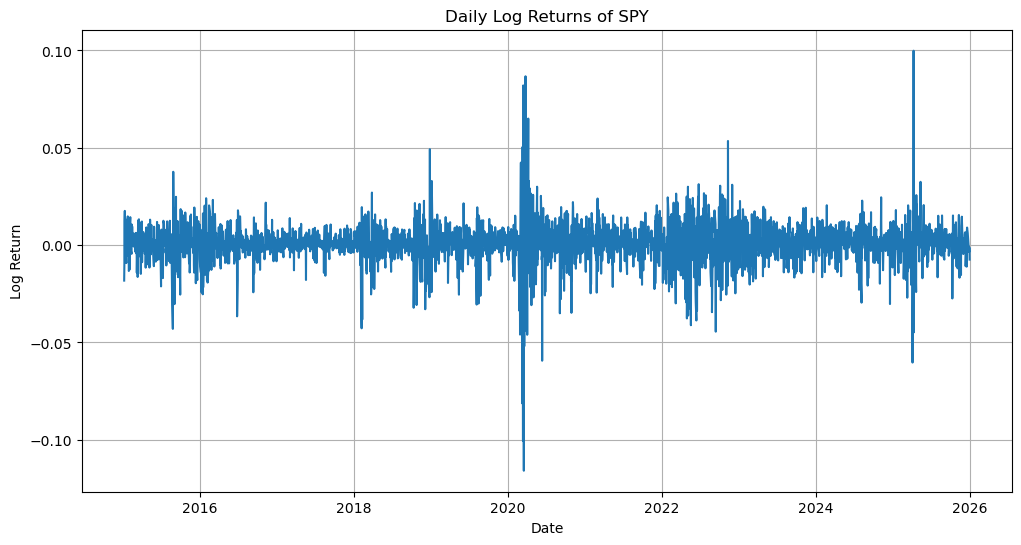

In [5]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Log_Return"])

plt.title("Daily Log Returns of SPY")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.grid(True)

plt.show()

Initially, this plot shows that daily log returns fluctuate around zero, with a relatively constant average, but there are some periods with much larger volatility.

## 5. Stationary Time Series

### 5.1 Statistical Properties

Commonly, time series assume stationarity which we can describe with three main statistical properties: 

- Constant mean:

$$
E(X_t) = \mu
$$

- Constant variance:

$$
Var(X_t) = \sigma ^2
$$

- Covariance depends only on the time difference, not absolute time:

$$
Cov(X_t,X_{t+k})
$$

This is often true for daily market returns, hence we can attempt to model this using a stationary time series model.

### 5.2 Augmented Dickey-Fuller Test

We begin this test with our hypotheses:

Null Hypothesis:

$H_0$ : The series has a unit root (not stationary)

Alternative Hypothesis:

$H_1$ : The series is stationary


In [6]:
adf_result = adfuller(spy["Log_Return"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -17.038316067009756
p-value: 8.230827976836096e-30


This is quite clearly evidence in favour of the null hypothesis as our p-value $8.230789471952073e-30$ is much smaller than a significance level of $0.05$, highlighting that the SPY daily log return series is indeed stationary. 

## 6. Rolling Mean and Variance

### 6.1 Rolling Mean

The rolling mean calculates the average return over the previous $n$ observations:

$$
\mu_t = \frac{1}{n} \sum^t_{i=t-n+1} r_i
$$

where:

- $\mu_t$ = rolling mean time at time $t$
- $r_i$ = daily log return
- $n$ = rolling window size (again picking $n=30$)

In [7]:
spy["Rolling_Mean"] = spy["Log_Return"].rolling(window=30).mean()

spy["Rolling_Mean"].iloc[30:35]

Date
2015-02-18    0.001362
2015-02-19    0.001653
2015-02-20    0.001440
2015-02-23    0.000849
2015-02-24    0.001211
Name: Rolling_Mean, dtype: float64

### 6.2 Rolling Variance

We also need to recall the rolling variance:

$$
\sigma_t^2 = \frac{1}{n-1} \sum^t_{i=t-n+1} (r_i - \mu_t)^2
$$

where:

- $\sigma^2_t$ = rolling variance
- $\mu_t$ = rolling mean return
- $n$ = rolling window size ($n=30$)

In [8]:
spy["Rolling_Variance"] = spy["Log_Return"].rolling(window=30).var()

spy["Rolling_Variance"].iloc[30:35]

Date
2015-02-18    0.000087
2015-02-19    0.000083
2015-02-20    0.000079
2015-02-23    0.000070
2015-02-24    0.000067
Name: Rolling_Variance, dtype: float64

### 6.3 Visualisations

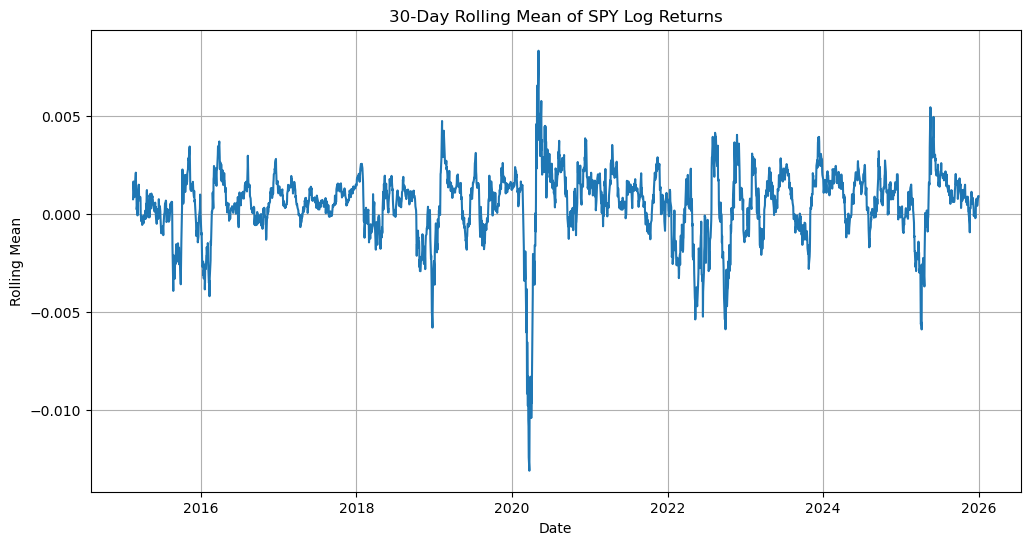

In [9]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Rolling_Mean"])

plt.title("30-Day Rolling Mean of SPY Log Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Mean")

plt.grid(True)

plt.show()

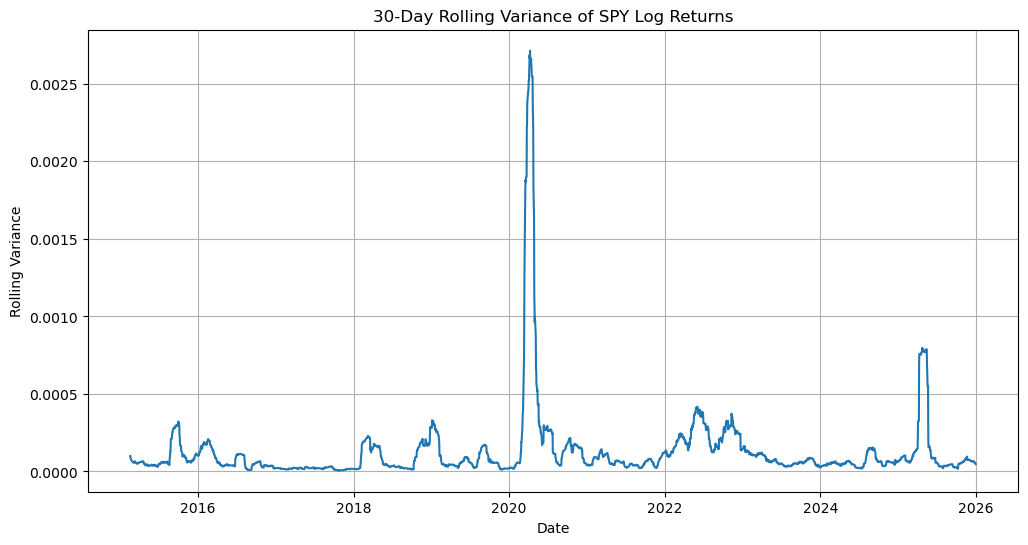

In [10]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Rolling_Variance"])

plt.title("30-Day Rolling Variance of SPY Log Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Variance")

plt.grid(True)

plt.show()

## 7. Autocorrelation Analysis

### 7.1 Autocorrelation Function (ACF)

The autocorrelation at lag $k$ measures the correlation between a time series and itself shifted by $k$ periods, given by:

$$ \rho_k = \frac{\sum^T_{t=k+1} (r_t -\bar{r})(r_{t-k} - \bar{r})}{\sum^T_{t=1} (r_t - \bar{r})^2} $$

where:

- $\rho_k$ = autocorrelation at lag $k$
- $r_t$ = return at time $k$
- $r_{t-k}$ = return $k$ periods earlier
- $\bar{r}$ = mean return

### 7.2 Plotting the ACF

<Figure size 1200x600 with 0 Axes>

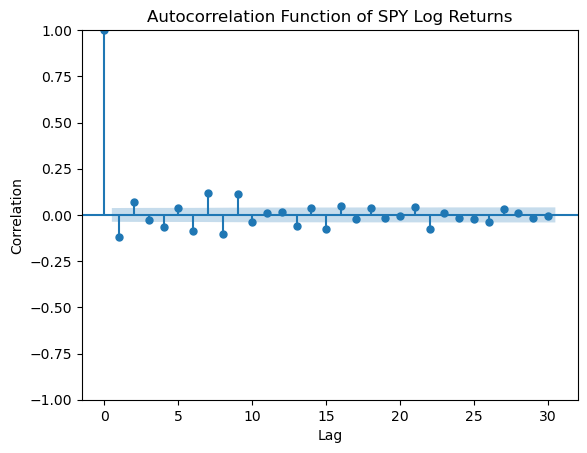

In [11]:
plt.figure(figsize=(12,6))

plot_acf(spy["Log_Return"], lags=30)

plt.title("Autocorrelation Function of SPY Log Returns")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.show()

Looking at this data we see a value of $1.00$ for lag $1$ and the rest of the lags appear to follow a trend with most values lying in the confidence interval. This indicates that daily SPY returns are approximately unpredictable, and the same can be said for the wider equity marekts.

## 8. Partial Autocorrelation Analysis (PACF)

The Partial Autocorrelation Analysis (PACF) now measures the direct correlation between $r_t$ and $r_{t-k}$ by removing the intermediate lags, and will later be used for the autoregressive model (AR) we introduce in the next chapter.

<Figure size 1200x600 with 0 Axes>

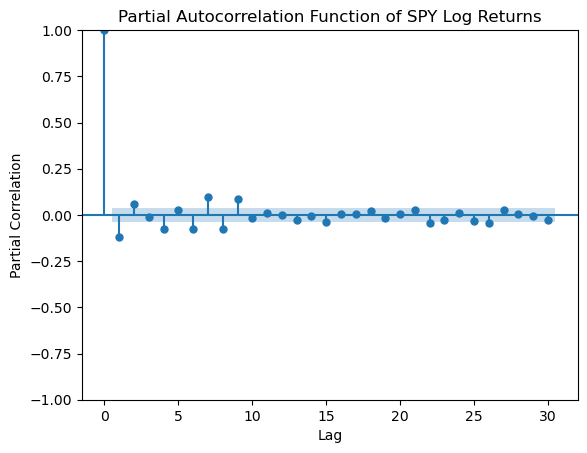

In [12]:
plt.figure(figsize=(12,6))

plot_pacf(spy["Log_Return"], lags=30)

plt.title("Partial Autocorrelation Function of SPY Log Returns")
plt.xlabel("Lag")
plt.ylabel("Partial Correlation")

plt.show()

Again we see most values within the 95% confidence interval, and it is also worth noting that as the lag increases it seems more likely that the PACF value is in this confidence interval, indicating there is minimal evidence of statistically significant direct dependence. Overall, it suggeststs that past returns provide little predictive information about future returns, consistent with the Efficient Market Hypothesis.

## 9. ARIMA Modelling

We now look into ARIMA models and see if we can efficiently capture the dynamics of SPY daily log returns and possibly use the model for short-term forecasts. Due to our discoveries in chapter 8, we may find this difficult due to low ACF and PACF values.

### 9.1 What is an ARIMA model? 

ARIMA stands for Autoregressive Integrated Moving Average, written $ARIMA(p,d,q)$ where:

- $p$ = autoregressive order
- $d$ = number of differences
- $q$ = moving average order

We previously saw that the daily returns are stationary, so let $d=0$ and begin with $ARIMA(1,0,1)$ written as:

$$ r_t = c + \phi_1 r_{t-1} + \theta_1 \epsilon_{t-1} + \epsilon_t $$

where:

- $r_t$ = return at time $t$
- $c$ = constant
- $\phi_1$ = autoregressive coefficient
- $\theta_1$ = moving average coefficient
- $\epsilon_t$ = random error term

### 9.2 Plot

In [13]:
model = ARIMA(spy["Log_Return"], order=(1,0,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 2765
Model:                 ARIMA(1, 0, 1)   Log Likelihood                8510.198
Date:                Thu, 30 Jul 2026   AIC                         -17012.396
Time:                        16:34:33   BIC                         -16988.697
Sample:                             0   HQIC                        -17003.836
                               - 2765                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.438      0.015    9.75e-05       0.001
ar.L1         -0.5541      0.042    -13.176      0.000      -0.637      -0.472
ma.L1          0.4426      0.045      9.795      0.0

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


There is a lot of information provided for the model, so let's break it down. Firstly we have AIC/BIC values. AIC (Akaike Information Criterion) is defined as $2k - 2 \ln(L) $ and the BIC (Bayesian Information Criterion) is defined as $k \ln(n) - 2 \ln(L) $ where $k$ is the number of parameters and $L$ is the maximum likelihood. We can use these values to assess how this model compares to other ARIMA models.

Next, with have an estimate for $c=0.0005$ for our constant, suggesting daily log returns increase slightly. The model predicts our $AR(1)$ coefficient $\phi_1 = -0.554$ which is a significantly negative value, implying a negative relationship between today's return and the previous day's return. The $MA(1)$ coefficient $\theta_1 = 0.443$ suggests that shocks from the previous day have a significant effect on today's returns.

Finally, we also see similar values to our previous notebook for negative skewness $(-0.66)$ and a very large kurtosis reading $(16.62)$, which we expect due to the reasoning explored previously. We could also infer from the heteroskedasticity reading $(1.86)$ shows non-constant variance (volatility) which we also find previously.

### 9.3 Five-Day Forecast

We can attempt to use this ARIMA model to forecast the next five days of trading:

In [14]:
forecast = model_fit.forecast(steps=5)

print(forecast)

2765    0.001372
2766    0.000013
2767    0.000766
2768    0.000349
2769    0.000580
Name: predicted_mean, dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Here we see readings very close to zero, which is expected because the daily return data exhibited very weak autocorrelation. However, we should compare this to the previous observations. 

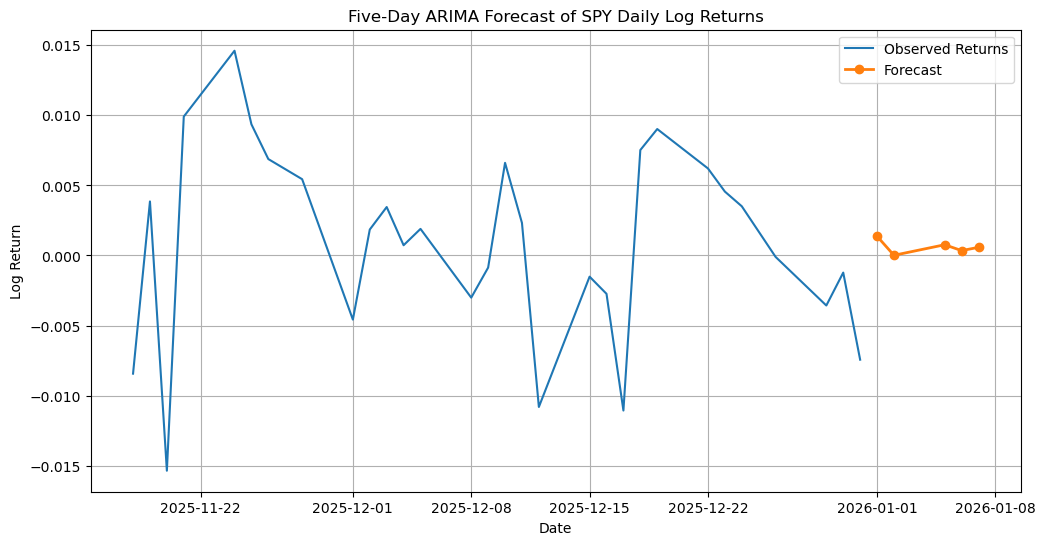

In [15]:
plt.figure(figsize=(12,6))

plt.plot(spy.index[-30:], spy["Log_Return"].iloc[-30:], label="Observed Returns")

forecast_index = pd.date_range(
    start=spy.index[-1] + pd.Timedelta(days=1),
    periods=5,
    freq="B"
)

plt.plot(forecast_index, forecast,
         marker="o",
         linewidth=2,
         label="Forecast")

plt.title("Five-Day ARIMA Forecast of SPY Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.legend()

plt.grid(True)

plt.show()

We can see that the forecast remains close to zero, which does not seem to effectively forecast the previously observed returns, and highlights the limitations to the models we have spoken of.

### 9.4 Out-of-Sample Forecast

It is not worthwhile accepting the fact that the five day forecast we saw previously does not match up with the real observations. To try to "train" the model to forecast correctly, we can use an out-of-sample forecast which continues to predict the next five days' returns at every time interval. First, we need to split the data then try to fit a new ARIMA model.

In [17]:
train = spy["Log_Return"].iloc[:-5]

test = spy["Log_Return"].iloc[-5:]

model = ARIMA(train, order=(1,0,1))

model_fit = model.fit()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [18]:
forecast = model_fit.forecast(steps=5)

print(forecast)

2760    0.000252
2761    0.000639
2762    0.000425
2763    0.000544
2764    0.000478
Name: predicted_mean, dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Now we can compare the two ARIMA models.

In [19]:
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast.values
})

print(comparison)

              Actual  Forecast
Date                          
2025-12-24  0.003512  0.000252
2025-12-26 -0.000101  0.000639
2025-12-29 -0.003570  0.000425
2025-12-30 -0.001222  0.000544
2025-12-31 -0.007437  0.000478


We can also introduce some measurements to assess the strength of the model, including the Mean Absolute Error (MAE):

$$ MAE = \frac{1}{n} \sum_{i=1}^n | y_i - \hat{y_i}| $$

where: 

- $y_i$ = observed return
- $\hat{y_i}$ = forecast return
- $n$ = number of forecasts

And also the Root Mean Square Error (RMSE):

$$ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y_i})^2} $$

In [20]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(
    comparison["Actual"],
    comparison["Forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Forecast"]
    )
)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

MAE: 0.003535
RMSE: 0.004310


The MAE provides a measure of the average forecasting error, while the RMSE places greater emphasis on larger predicition errors, but together they provide measures of the accuracy of the forecast.

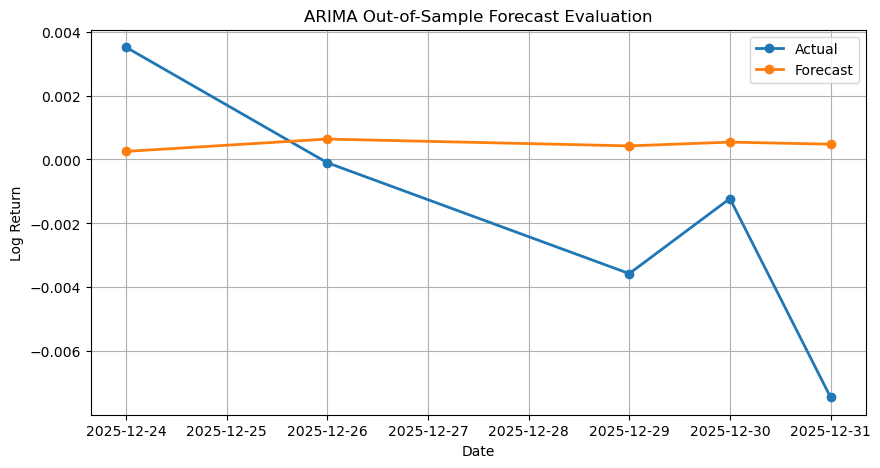

In [21]:
plt.figure(figsize=(10,5))

plt.plot(comparison.index,
         comparison["Actual"],
         marker="o",
         linewidth=2,
         label="Actual")

plt.plot(comparison.index,
         comparison["Forecast"],
         marker="o",
         linewidth=2,
         label="Forecast")

plt.title("ARIMA Out-of-Sample Forecast Evaluation")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.legend()
plt.grid(True)

plt.show()

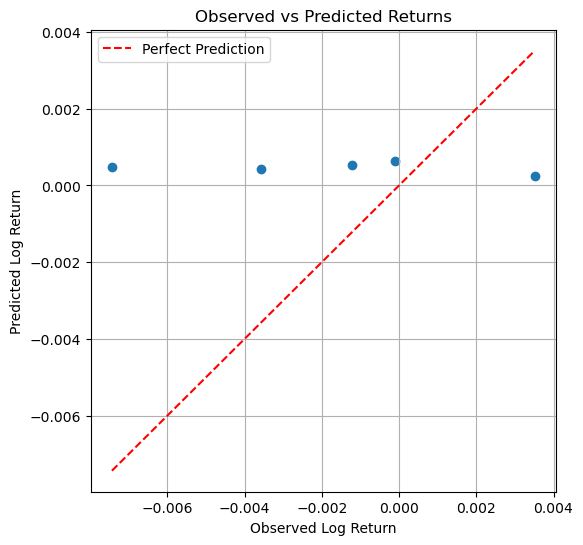

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(comparison["Actual"],
            comparison["Forecast"])

plt.plot(
    [comparison["Actual"].min(), comparison["Actual"].max()],
    [comparison["Actual"].min(), comparison["Actual"].max()],
    "r--",
    label="Perfect Prediction"
)

plt.title("Observed vs Predicted Returns")
plt.xlabel("Observed Log Return")
plt.ylabel("Predicted Log Return")

plt.legend()

plt.grid(True)

plt.show()